# Geographic and Comparative Analysis

- Which countries are winning bs losing?
- High burden regions
- Urban vs Rural - who is worse?
- Resource allocation.

#### Country comparisons

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Initial setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
warnings.filterwarnings('ignore')

In [18]:
# Data preparation

# Load data
geo_types = {
    "urban_rural": "category"
}

fac_types = {
    "facility_type": "category",
    "facility_level": "category",
    "operation_status": "category",
    "established_year": "category"
}

reports_types = {
   "disease": "category",
   "age_group": "category",
   "gender": "category" 
}

reports = pd.read_csv('../data/processed/reports_clean.csv', dtype=reports_types)
geo = pd.read_csv('../data/processed/geographical_clean.csv', dtype=geo_types)
facilities = pd.read_csv('../data/processed/facilities_clean.csv', dtype=fac_types)

# Convert dates
reports['report_date'] = pd.to_datetime(reports['report_date'])

# Merge reports with geo data
reports_geo = reports.merge(
    geo[['geography_id', 'country_code', 'country_name', 'region_name', 'district_name', 'population', 'urban_rural']],
    on='geography_id',
    how='left'
)

#### Country burden

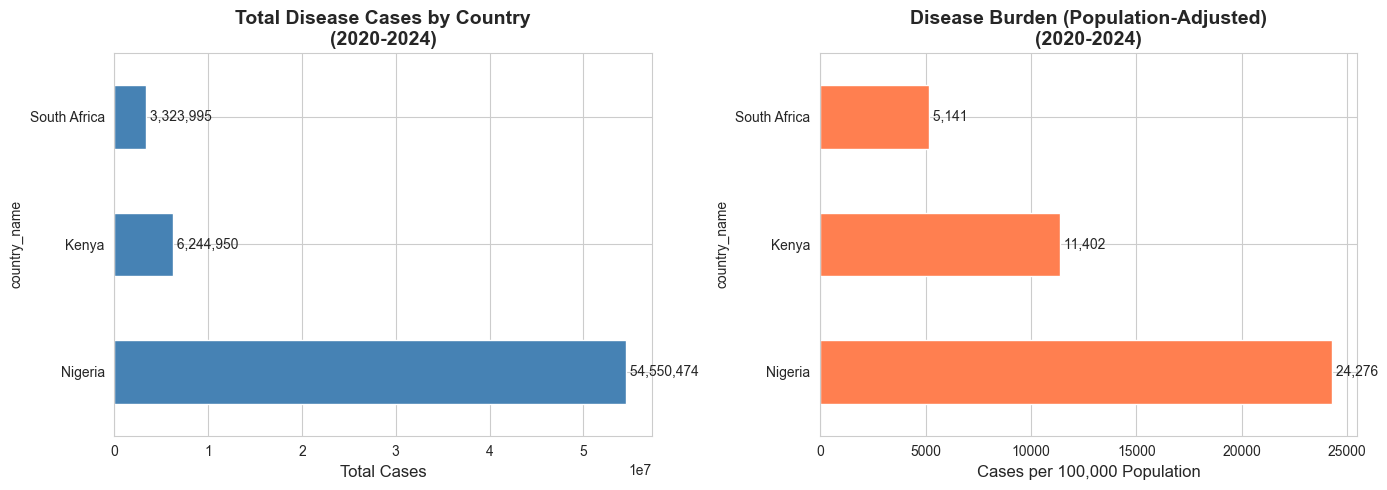


Highest absolute burden: Nigeria
Highest per-capita burden: Nigeria


In [33]:
# Overall Total burden
country_burden = reports_geo.groupby('country_name').agg({
    'cases': 'sum',
    'deaths': 'sum',
    'report_date': 'count'
}).round(0)

country_burden.columns = ['total_cases', 'total_deaths', 'reports']

country_burden['fatality_rate(%)'] = round((country_burden['total_deaths'] / country_burden['total_cases']) * 100, 2)
country_burden['population'] = geo.groupby('country_name')['population'].sum()

country_burden['cases_per_100k'] = (country_burden['total_cases'] / country_burden['population'] * 100000).round(1)
country_burden['cases_per_year'] = (country_burden['total_cases'] / 5).round(1)

# Sort by total cases
country_burden = country_burden.sort_values('total_cases', ascending=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
country_burden['total_cases'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Total Cases', fontsize=12)
ax1.set_title('Total Disease Cases by Country\n(2020-2024)', fontsize=14, fontweight='bold')
for i, v in enumerate(country_burden['total_cases']):
    ax1.text(v, i, f' {v:,.0f}', va='center')

ax2 = axes[1]
country_burden['cases_per_100k'].plot(kind='barh', ax=ax2, color='coral')
ax2.set_xlabel('Cases per 100,000 Population', fontsize=12)
ax2.set_title('Disease Burden (Population-Adjusted)\n(2020-2024)', fontweight='bold', fontsize=14)
for i, v in enumerate(country_burden['cases_per_100k']):
    ax2.text(v, i, f' {v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../src/images/countyburden.png')
plt.show()

print()
print(f'Highest absolute burden: {country_burden.index[0]}')
print(f'Highest per-capita burden: {country_burden["cases_per_100k"].idxmax()}')
if country_burden.index[0] != country_burden['cases_per_100k'].idxmax():
    print(f'{country_burden.index[0]} has more cases but {country_burden["cases_per_100k"].idxmax()} has more cases per 100,000 population')

#### Country Trends over time